# 11 — Outliers: detección estratificada y tratamiento aditivo

Un valor extremo en este dataset **no es un error**. Un juzgado civil de Santa
Cruz atiende un orden de magnitud más causas que uno de Pando, y eso es el
fenómeno que se quiere medir, no ruido que haya que sacar.

De ahí las dos decisiones del paso:

1. **La detección se estratifica** por `materia_homologada × ambito`. Comparar
   la carga de una capital con la de una provincia produciría outliers falsos en
   masa.
2. **Regla de cero eliminación.** Ninguna fila se borra y ningún valor se pisa.
   Todo el tratamiento es aditivo: se marcan banderas, se agregan versiones
   winsorizadas y logarítmicas **al lado** de las columnas originales.

Los tres tratamientos aditivos que aplica este paso:

| tratamiento | qué agrega | para qué |
|---|---|---|
| **banderas IQR** (Tukey) | 8 columnas `es_outlier_*` | marcar sin excluir; leve a 1,5·IQR, severo a 3·IQR |
| **winsorización** al P95 por estrato | 2 columnas `*_winsorizada` | acotar colas infinitas conservando el orden |
| **log(1 + x)** | 5 columnas `log_*` | comprimir escalas de volumen para modelos futuros |

In [1]:
# --- Arranque -------------------------------------------------------------
# Define __file__ apuntando al script original para que las rutas del proyecto
# resuelvan igual que al correr `python src/analysis/<script>.py`.
import os, sys
from pathlib import Path

RAIZ_PROYECTO = Path.cwd().resolve()
while not (RAIZ_PROYECTO / "src" / "comun.py").exists():
    if RAIZ_PROYECTO.parent == RAIZ_PROYECTO:
        raise RuntimeError("Abrí el notebook desde dentro del repositorio.")
    RAIZ_PROYECTO = RAIZ_PROYECTO.parent

__file__ = str(RAIZ_PROYECTO / "src" / "analysis" / "11_tratamiento_outliers.py")
os.chdir(RAIZ_PROYECTO)
sys.path.insert(0, str(RAIZ_PROYECTO / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 180)

# Paleta categórica validada (separación CVD ΔE 9,1; contraste bajo en verde y
# ámbar, por eso todos los gráficos llevan el valor escrito encima).
AZUL, NARANJA, VERDE, AMBAR = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
TINTA, TINTA_2, RULE = "#15202a", "#56606b", "#d9d6ce"
RAMPA_AZUL = ["#eaf2fd", "#b7d3f6", "#6da7ec", "#2a78d6", "#1c5cab", "#0d366b"]

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.labelsize": 9.5, "axes.labelcolor": TINTA_2,
    "axes.edgecolor": RULE, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.linestyle": ":", "grid.alpha": 0.55, "grid.color": RULE,
    "xtick.color": TINTA_2, "ytick.color": TINTA_2,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "legend.frameon": False,
})

import textwrap

def envolver(texto, ancho=17):
    """Parte un rótulo largo en varias líneas en vez de truncarlo."""
    return textwrap.fill(str(texto), ancho)

def etiquetar_barh(ax, valores, fmt="{:,.0f}", dx=None):
    """Escribe el valor al final de cada barra horizontal."""
    dx = dx if dx is not None else max(valores) * 0.012
    for i, v in enumerate(valores):
        ax.text(v + dx, i, fmt.format(v), va="center", fontsize=9,
                fontweight="bold", color=TINTA)

print("raíz:", RAIZ_PROYECTO)

raíz: C:\maxi\u\anal\congestion-judicial-bolivia


In [2]:
from scipy.stats import spearmanr
from analysis.outliers import aplicar_transformaciones_curadas, calcular_estadisticas_iqr

DATA = RAIZ_PROYECTO / "data/curated/features/dataset_analitico_indicadores.parquet"
OUT_FEATURES = RAIZ_PROYECTO / "data/curated/features"
OUT_EDA = RAIZ_PROYECTO / "data/curated/eda"
OUT_FIG = RAIZ_PROYECTO / "reports/figures"
for d in (OUT_FEATURES, OUT_EDA, OUT_FIG):
    d.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(DATA)
columnas_originales = list(df.columns)
print(f"entrada: {len(df):,} filas x {len(df.columns)} columnas")

entrada: 1,997 filas x 100 columnas


## 1. Por qué hay que estratificar

La misma variable, `atendidas`, vista sin estratificar y vista por ámbito. Si el
umbral de Tukey se calcula sobre el total, casi toda la capital cae del lado
"outlier" simplemente por ser capital.

In [3]:
p = df[df["tipo_elemento_analitico"] == "proceso"]

glob = calcular_estadisticas_iqr(p["atendidas"])
print("umbral global (sin estratificar)")
print(f"  Q1={glob['q1']:.0f}  mediana={glob['mediana']:.0f}  Q3={glob['q3']:.0f}  "
      f"límite leve={glob['limite_sup']:.0f}")

filas = []
for (mat, amb), g in p.groupby(["materia_homologada", "ambito"], observed=True):
    s = calcular_estadisticas_iqr(g["atendidas"])
    filas.append({"materia": mat[:34], "ambito": amb, "n": s["n"],
                  "mediana": s["mediana"], "Q3": s["q3"], "limite_leve": s["limite_sup"]})
pd.DataFrame(filas).sort_values(["materia", "ambito"]).round(1)

umbral global (sin estratificar)
  Q1=0  mediana=9  Q3=78  límite leve=195


,materia,ambito,n,mediana,Q3,limite_leve
0,Partido Administrativo Coactivo Fi,capital,40,37.5,113.0,281.4
1,Partido de Trabajo y Seguridad Soc,capital,120,40.5,361.0,901.0
2,Partido de Trabajo y Seguridad Soc,provincia,108,1.0,20.2,50.6
3,Público Civil y Comercial,capital,250,24.5,165.5,407.8
4,Público Civil y Comercial,provincia,225,9.0,69.0,172.5
5,Público Niñez y Adolescencia,capital,250,6.0,36.8,91.9
6,Público Niñez y Adolescencia,provincia,225,3.0,14.0,35.0
7,Público de Familia,capital,230,28.0,170.5,423.2
8,Público de Familia,provincia,207,8.0,80.5,199.8


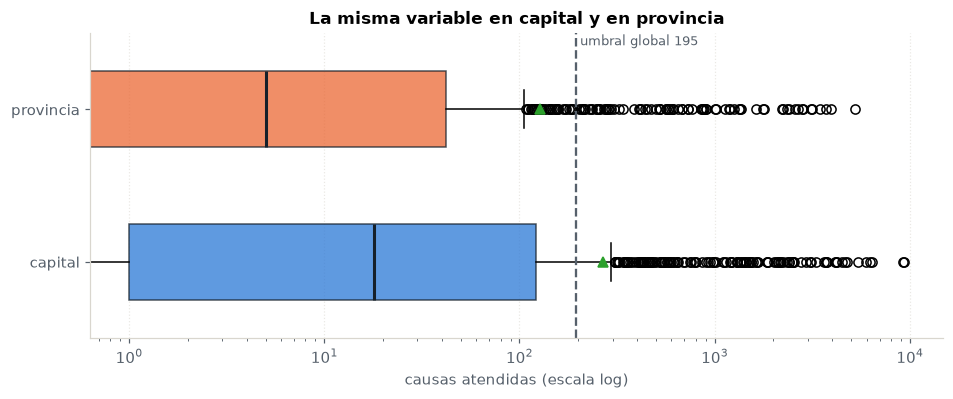

In [4]:
fig, ax = plt.subplots(figsize=(10, 3.6))
datos, etiquetas, colores = [], [], []
for amb, color in [("capital", AZUL), ("provincia", NARANJA)]:
    datos.append(p[p["ambito"] == amb]["atendidas"].dropna().values)
    etiquetas.append(amb); colores.append(color)
bp = ax.boxplot(datos, tick_labels=etiquetas, orientation="horizontal",
                showmeans=True, widths=.5, patch_artist=True)
for caja, c in zip(bp["boxes"], colores):
    caja.set_facecolor(c); caja.set_alpha(.75); caja.set_edgecolor(TINTA)
for m in bp["medians"]:
    m.set_color(TINTA); m.set_linewidth(2)
ax.axvline(glob["limite_sup"], color=TINTA_2, ls="--", lw=1.5)
ax.text(glob["limite_sup"], 2.42, f" umbral global {glob['limite_sup']:.0f}",
        fontsize=8.5, color=TINTA_2)
ax.set_xscale("log")
ax.set_xlabel("causas atendidas (escala log)")
ax.set_title("La misma variable en capital y en provincia")
ax.grid(axis="y", visible=False)
plt.show()

## 2. Aplicar los tres tratamientos

In [5]:
df_curado, tabla_umbrales = aplicar_transformaciones_curadas(df)
nuevas = [c for c in df_curado.columns if c not in columnas_originales]

grupo = {}
for c in nuevas:
    if c.startswith("es_outlier"):   grupo[c] = "bandera IQR"
    elif c.endswith("winsorizada"):  grupo[c] = "winsorización P95"
    elif c.startswith("log_"):       grupo[c] = "log(1 + x)"
    else:                            grupo[c] = "otro"

inv = pd.DataFrame({
    "columna_nueva": nuevas,
    "tratamiento": [grupo[c] for c in nuevas],
    "tipo": [str(df_curado[c].dtype) for c in nuevas],
    "no_nulos": [int(df_curado[c].notna().sum()) for c in nuevas],
})
print(f"columnas antes: {len(columnas_originales)}   después: {len(df_curado.columns)}   "
      f"agregadas: {len(nuevas)}")
print(inv.groupby("tratamiento")["columna_nueva"].count().to_string())
inv

columnas antes: 100   después: 115   agregadas: 15
tratamiento
bandera IQR          8
log(1 + x)           5
winsorización P95    2


,columna_nueva,tratamiento,tipo,no_nulos
0,es_outlier_carga_iqr,bandera IQR,bool,1997
1,es_outlier_severo_carga_iqr,bandera IQR,bool,1997
2,es_outlier_ingresos_iqr,bandera IQR,bool,1997
3,es_outlier_severo_ingresos_iqr,bandera IQR,bool,1997
4,es_outlier_congestion_iqr,bandera IQR,bool,1997
5,es_outlier_severo_congestion_iqr,bandera IQR,bool,1997
6,es_outlier_duracion_iqr,bandera IQR,bool,1997
7,es_outlier_severo_duracion_iqr,bandera IQR,bool,1997
8,tasa_congestion_winsorizada,winsorización P95,float64,1173
9,duracion_estimada_winsorizada,winsorización P95,float64,1173


In [6]:
intactas = df_curado[columnas_originales].equals(df[columnas_originales])
print(f"filas preservadas            : {len(df_curado):,} / {len(df):,}  (cero eliminadas)")
print(f"columnas originales intactas : {intactas}")
assert intactas and len(df_curado) == 1997

filas preservadas            : 1,997 / 1,997  (cero eliminadas)
columnas originales intactas : True


## 3. Cuántos outliers hay

Leve = por encima de `Q3 + 1,5·IQR` dentro de su estrato. Severo = por encima de
`Q3 + 3·IQR`. Un severo es siempre también leve.

In [7]:
sub = df_curado[df_curado["tipo_elemento_analitico"] == "proceso"]
pares = [("Carga atendidas", "es_outlier_carga_iqr", "es_outlier_severo_carga_iqr"),
         ("Nuevas ingresadas", "es_outlier_ingresos_iqr", "es_outlier_severo_ingresos_iqr"),
         ("Tasa de congestión", "es_outlier_congestion_iqr", "es_outlier_severo_congestion_iqr"),
         ("Duración estimada", "es_outlier_duracion_iqr", "es_outlier_severo_duracion_iqr")]

conteo_out = pd.DataFrame([{
    "variable": rot,
    "outliers_leves": int(sub[leve].sum()),
    "pct_leves": round(sub[leve].sum() / len(sub) * 100, 1),
    "outliers_severos": int(sub[sev].sum()),
    "pct_severos": round(sub[sev].sum() / len(sub) * 100, 1),
} for rot, leve, sev in pares])
print(f"universo evaluado: {len(sub):,} procesos")
conteo_out

universo evaluado: 1,655 procesos


,variable,outliers_leves,pct_leves,outliers_severos,pct_severos
0,Carga atendidas,244,14.7,184,11.1
1,Nuevas ingresadas,246,14.9,170,10.3
2,Tasa de congestión,97,5.9,53,3.2
3,Duración estimada,96,5.8,53,3.2


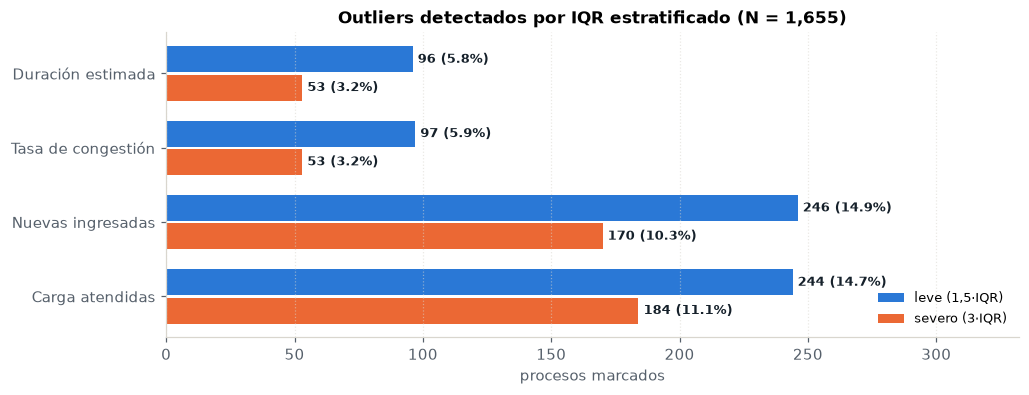

In [8]:
y = np.arange(len(conteo_out))
fig, ax = plt.subplots(figsize=(10, 3.6))
ax.barh(y + .19, conteo_out["outliers_leves"], height=.35, color=AZUL, label="leve (1,5·IQR)")
ax.barh(y - .19, conteo_out["outliers_severos"], height=.35, color=NARANJA, label="severo (3·IQR)")
for i, r in conteo_out.iterrows():
    ax.text(r["outliers_leves"] + 2, i + .19, f"{r['outliers_leves']} ({r['pct_leves']}%)",
            va="center", fontsize=8.5, fontweight="bold", color=TINTA)
    ax.text(r["outliers_severos"] + 2, i - .19, f"{r['outliers_severos']} ({r['pct_severos']}%)",
            va="center", fontsize=8.5, fontweight="bold", color=TINTA)
ax.set_yticks(y); ax.set_yticklabels(conteo_out["variable"])
ax.set_xlim(0, conteo_out["outliers_leves"].max() * 1.35)
ax.set_xlabel("procesos marcados")
ax.set_title(f"Outliers detectados por IQR estratificado (N = {len(sub):,})")
ax.grid(axis="y", visible=False)
ax.legend(fontsize=8.5, loc="lower right")
plt.show()

In [9]:
# Dónde se concentran: outliers de carga por estrato.
por_estrato = (sub.groupby(["materia_homologada", "ambito"], observed=True)
                  .agg(procesos=("tipo_proceso", "count"),
                       out_carga=("es_outlier_carga_iqr", "sum"),
                       out_congestion=("es_outlier_congestion_iqr", "sum"),
                       out_duracion=("es_outlier_duracion_iqr", "sum"))
                  .reset_index())
por_estrato["pct_carga"] = (por_estrato["out_carga"] / por_estrato["procesos"] * 100).round(1)
por_estrato.sort_values("out_carga", ascending=False)

,materia_homologada,ambito,procesos,out_carga,out_congestion,out_duracion,pct_carga
3,Público Civil y Comercial,capital,250,43,18,18,17.2
4,Público Civil y Comercial,provincia,225,38,13,13,16.9
6,Público Niñez y Adolescencia,provincia,225,34,11,11,15.1
8,Público de Familia,provincia,207,31,16,16,15.0
7,Público de Familia,capital,230,30,10,10,13.0
5,Público Niñez y Adolescencia,capital,250,28,17,17,11.2
2,Partido de Trabajo y Seguridad Social,provincia,108,19,5,5,17.6
1,Partido de Trabajo y Seguridad Social,capital,120,13,5,5,10.8
0,Partido Administrativo Coactivo Fiscal y Tribu...,capital,40,8,2,1,20.0


## 4. Qué le hace la winsorización a la distribución

Los cuatro paneles son el antes y el después de los dos tratamientos que tocan
la escala. Las columnas originales siguen ahí: esto se calcula **al lado**.

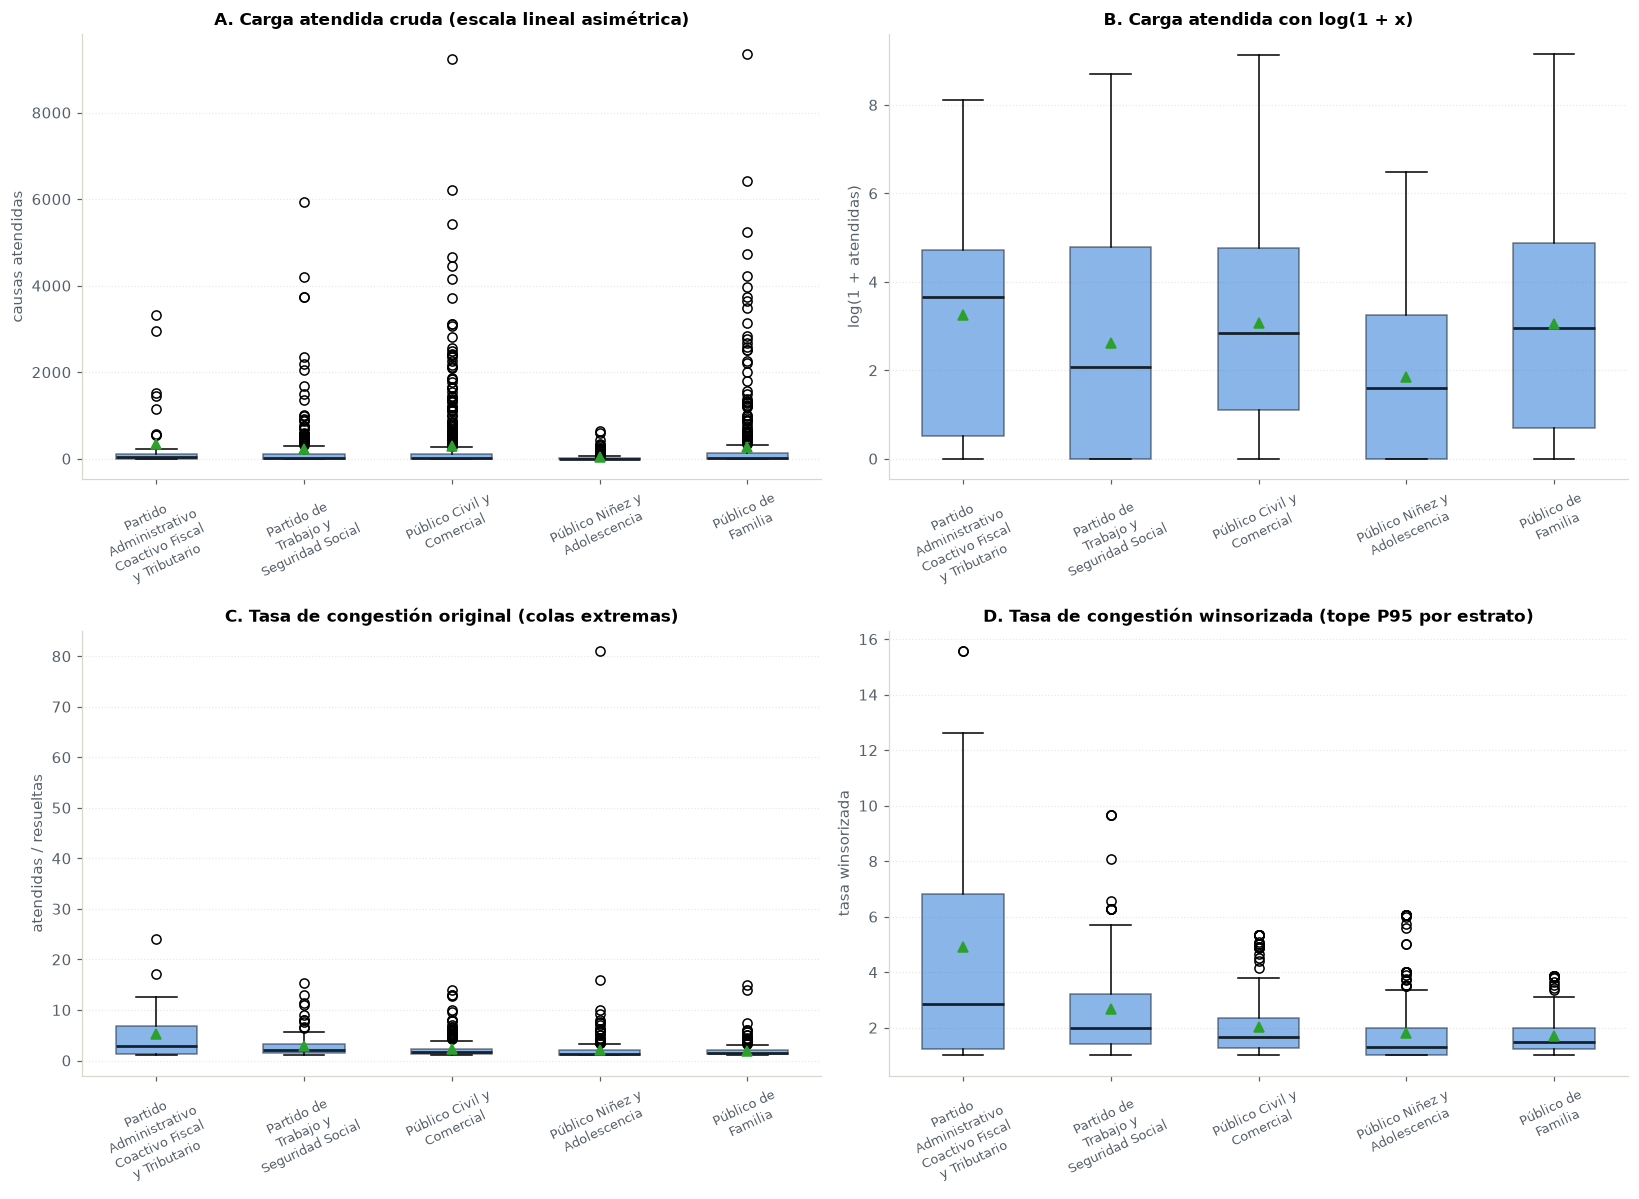

In [10]:
materias = sorted(sub["materia_homologada"].unique())
con_tc = sub[sub["tasa_congestion"].notnull()]
corto = [envolver(m, 16) for m in materias]

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
paneles = [
    (axes[0, 0], sub, "atendidas", "A. Carga atendida cruda (escala lineal asimétrica)", "causas atendidas"),
    (axes[0, 1], sub, "log_atendidas", "B. Carga atendida con log(1 + x)", "log(1 + atendidas)"),
    (axes[1, 0], con_tc, "tasa_congestion", "C. Tasa de congestión original (colas extremas)", "atendidas / resueltas"),
    (axes[1, 1], con_tc, "tasa_congestion_winsorizada", "D. Tasa de congestión winsorizada (tope P95 por estrato)", "tasa winsorizada"),
]
for ax, fuente, col, titulo, ylab in paneles:
    datos = [fuente[fuente["materia_homologada"] == m][col].dropna().values for m in materias]
    bp = ax.boxplot(datos, tick_labels=corto, showmeans=True, patch_artist=True, widths=.55)
    for caja in bp["boxes"]:
        caja.set_facecolor(AZUL); caja.set_alpha(.55); caja.set_edgecolor(TINTA)
    for m_ in bp["medians"]:
        m_.set_color(TINTA); m_.set_linewidth(1.8)
    ax.set_title(titulo); ax.set_ylabel(ylab)
    ax.tick_params(axis="x", rotation=25, labelsize=8.5)
    ax.grid(axis="x", visible=False)

plt.tight_layout()
plt.savefig(OUT_FIG / "02_boxplots_outliers_iqr.png")
plt.show()

## 5. El tratamiento no reordena nada

Una transformación aditiva solo sirve si conserva el orden de los casos: si
después de winsorizar un despacho más congestionado apareciera como menos
congestionado, el tratamiento estaría mintiendo. Spearman ≈ 1 confirma que no
pasa.

In [11]:
corr_log, _ = spearmanr(sub["atendidas"], sub["log_atendidas"])
corr_win, _ = spearmanr(con_tc["tasa_congestion"], con_tc["tasa_congestion_winsorizada"])
print(f"Spearman atendidas vs log_atendidas                    : {corr_log:.4f}")
print(f"Spearman tasa_congestion vs tasa_congestion_winsorizada: {corr_win:.4f}")

n_topeados = int((con_tc["tasa_congestion"] > con_tc["tasa_congestion_winsorizada"]).sum())
print(f"\nvalores efectivamente topeados por la winsorización   : {n_topeados} "
      f"({n_topeados / len(con_tc) * 100:.1f} % de los que tienen tasa definida)")

Spearman atendidas vs log_atendidas                    : 1.0000
Spearman tasa_congestion vs tasa_congestion_winsorizada: 0.9994

valores efectivamente topeados por la winsorización   : 59 (5.3 % de los que tienen tasa definida)


## 6. Artefactos

In [12]:
df_curado.to_parquet(OUT_FEATURES / "dataset_analitico_curado.parquet", index=False)
df_curado.to_csv(OUT_FEATURES / "dataset_analitico_curado.csv", index=False, encoding="utf-8")
tabla_umbrales.to_csv(OUT_EDA / "resumen_outliers_estratificado.csv", index=False, encoding="utf-8")

print("escritos:")
print("  data/curated/features/dataset_analitico_curado.parquet")
print("  data/curated/features/dataset_analitico_curado.csv")
print("  data/curated/eda/resumen_outliers_estratificado.csv")
print("  reports/figures/02_boxplots_outliers_iqr.png")
print(f"\n{len(columnas_originales)} columnas -> {len(df_curado.columns)} columnas "
      f"(+{len(nuevas)} aditivas, 0 sobrescritas, 0 filas eliminadas)")
tabla_umbrales.head(10).round(2)

escritos:
  data/curated/features/dataset_analitico_curado.parquet
  data/curated/features/dataset_analitico_curado.csv
  data/curated/eda/resumen_outliers_estratificado.csv
  reports/figures/02_boxplots_outliers_iqr.png

100 columnas -> 115 columnas (+15 aditivas, 0 sobrescritas, 0 filas eliminadas)


,n,q1,mediana,q3,iqr,limite_inf,limite_sup,limite_severo,p95,estrato,columna,n_outliers,n_severos
0,40,0.75,37.5,113.00,112.25,0.0,281.38,449.75,1597.85,Partido Administrativo Coactivo Fiscal y Tribu...,atendidas,8,8
1,120,1.00,40.5,361.00,360.00,0.0,901.00,1441.00,2065.30,Partido de Trabajo y Seguridad Social __ capital,atendidas,13,9
2,108,0.00,1.0,20.25,20.25,0.0,50.62,81.00,427.85,Partido de Trabajo y Seguridad Social __ provi...,atendidas,19,16
3,250,4.00,24.5,165.50,161.50,0.0,407.75,650.00,2144.60,Público Civil y Comercial __ capital,atendidas,43,33
4,225,0.00,9.0,69.00,69.00,0.0,172.50,276.00,1109.60,Público Civil y Comercial __ provincia,atendidas,38,30
5,250,0.00,6.0,36.75,36.75,0.0,91.88,147.00,190.55,Público Niñez y Adolescencia __ capital,atendidas,28,18
6,225,0.00,3.0,14.00,14.00,0.0,35.00,56.00,90.80,Público Niñez y Adolescencia __ provincia,atendidas,34,24
7,230,2.00,28.0,170.50,168.50,0.0,423.25,676.00,1537.70,Público de Familia __ capital,atendidas,30,22
8,207,1.00,8.0,80.50,79.50,0.0,199.75,319.00,1236.50,Público de Familia __ provincia,atendidas,31,24
9,40,0.00,12.0,53.75,53.75,0.0,134.38,215.00,191.60,Partido Administrativo Coactivo Fiscal y Tribu...,nuevas_ingresadas,5,2
